> [返回仓库首页](../README.md) · [查看可视化学习路线](../docs/learning-roadmap.md)

建议按路线图顺序学习本章。

# 02 逻辑回归：概率建模、交叉熵与二分类

**本章目标**：理解逻辑回归如何把线性得分转成类别概率，能从 Bernoulli 似然推导交叉熵，
并完成 NumPy 手写、sklearn 分类调用和乳腺癌案例评估。

> 数据来自固定随机种子或 sklearn 内置数据；选择包含 NumPy、Matplotlib、scikit-learn 的内核后可直接 Run All。

## 模型简介与学习参考

逻辑回归（Logistic Regression）是经典的概率二分类模型：先计算线性得分，再用 Sigmoid 输出类别 1 的概率。

| 项目 | 内容 |
|---|---|
| **模型定位** | 输出类别概率的监督学习分类模型 |
| **核心思想** | 用 Sigmoid 将线性得分映射到 0–1，并用交叉熵学习参数 |
| **适用任务** | 风险判断、疾病诊断、点击预测和是否违约等二分类问题 |
| **主要优点** | 训练快速、概率和系数可解释、可作为强基线 |
| **主要限制** | 原始边界为线性，对复杂非线性关系表达有限 |

**学习参考**：

- 周志华：《机器学习》（西瓜书），第 3 章“线性模型”；
- [Datawhale《南瓜书》](https://github.com/datawhalechina/pumpkin-book)；
- [hands-on-ML：逻辑回归 Notebook](https://github.com/ForceInjection/hands-on-ML/blob/main/nju_software/ch-03/02_logistic_regression.ipynb)；
- [scikit-learn：LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)。

本章按照 **原理推导 → NumPy 手写 → sklearn 调用 → 真实案例 → 章节小结** 展开。

## 目录

- [1. 原理与数学推导](#theory)
  - [1.1 分类起点：二分类与线性得分](#problem)
  - [1.2 概率映射：对数几率与 Sigmoid](#logit-sigmoid)
  - [1.3 损失推导：Bernoulli 似然与交叉熵](#cross-entropy)
  - [1.4 梯度更新：p-y 与参数优化](#gradient)
  - [1.5 分类决策：概率阈值与评估指标](#metrics)
  - [1.6 完整链路：从特征到类别](#full-chain)
  - [1.7 代码对应：公式与实现](#formula-code)
- [2. NumPy 手写逻辑回归](#scratch)
  - [2.1 图形复现：三张核心原理图](#figure-code)
  - [2.2 数据准备：二维高斯模拟数据](#scratch-data)
  - [2.3 模型实现：LogisticRegressionGD](#scratch-model)
  - [2.4 训练评估：Loss、边界与分类指标](#scratch-evaluation)
- [3. sklearn 调用与案例](#sklearn)
  - [3.1 分类调用：决策边界与指标评估](#sklearn-basic)
  - [3.2 分类案例：乳腺癌良恶性诊断](#real-case)
- [4. 章节小结](#summary)

<a id="theory"></a>
## 1. 原理与数学推导

<a id="problem"></a>
### 1.1 分类起点：二分类与线性得分

以肿瘤分类为例，输入是半径、纹理等特征
\(\boldsymbol x\)，输出只有两类：

$$
y\in\{0,1\}
$$

我们不只想输出 0 或 1，还希望得到
\(p=P(y=1\mid\boldsymbol x)\)，例如“属于类别 1 的概率为 0.82”。

如果直接使用线性模型

$$
z=\boldsymbol w^\mathrm T\boldsymbol x+b
$$

会遇到一个问题：\(z\) 的范围是 \((-\infty,+\infty)\)，而概率必须位于
\([0,1]\)。因此需要在“线性得分”和“概率”之间建立桥梁。

<a id="logit-sigmoid"></a>
### 1.2 概率映射：对数几率与 Sigmoid

**为什么叫逻辑回归？** 它不是用来预测连续值，而是对类别 1 的对数几率进行线性回归，再通过 Sigmoid 把线性结果还原为概率，因此最终用于分类。

概率 \(p\) 对应的**几率（odds）**定义为

$$
\operatorname{odds}
=\frac{p}{1-p}
$$

例如 \(p=0.8\) 时，几率为 \(0.8/0.2=4\)，表示类别 1 出现的可能性
是类别 0 的 4 倍。几率只能取正数；再取对数后，范围变为整个实数：

$$
\operatorname{logit}(p)
=\log\frac{p}{1-p}
\in(-\infty,+\infty)
$$

逻辑回归的核心假设是：**类别 1 的对数几率是特征的线性组合**。

$$
\log\frac{p}{1-p}
=
\boldsymbol w^\mathrm T\boldsymbol x+b
=z
$$

从这个等式反解 \(p\)：

$$
\frac{p}{1-p}=e^z
\quad\Longrightarrow\quad
p=e^z(1-p)
\quad\Longrightarrow\quad
p=\frac{e^z}{1+e^z}
=\frac1{1+e^{-z}}
$$

这就是 sigmoid 函数：

$$
p=\sigma(z)=\frac1{1+\exp(-z)}
$$

所以逻辑回归虽然用于**分类**，但它“回归”的对象是对数几率。
当 \(z=0\) 时，\(p=0.5\)；因此默认阈值 \(p=0.5\) 对应的决策边界就是
\(\boldsymbol w^\mathrm T\boldsymbol x+b=0\)。

权重也有明确含义：其他特征不变时，\(x_j\) 增加 1，
对数几率增加 \(w_j\)，几率变为原来的 \(e^{w_j}\) 倍。

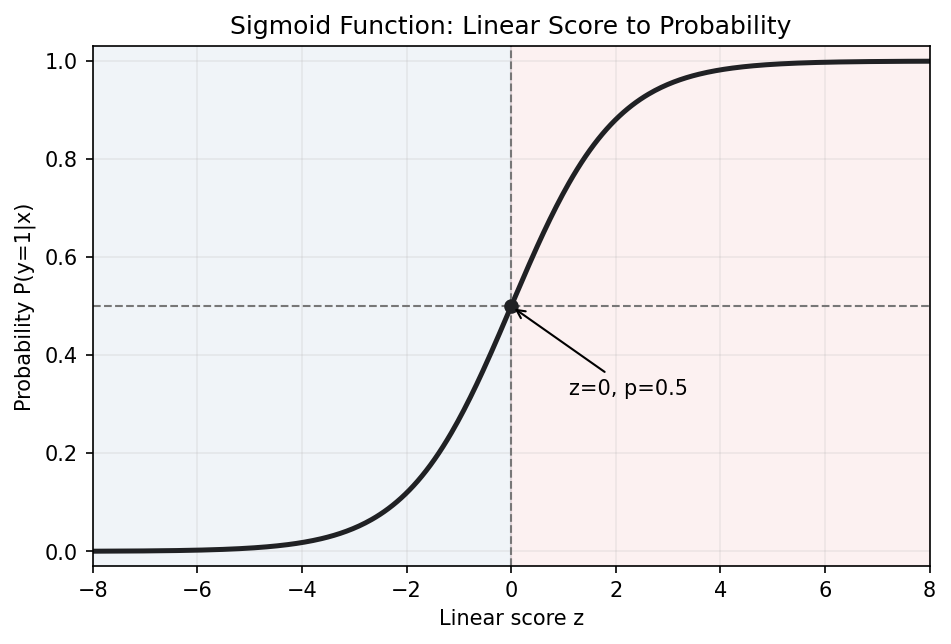

<a id="cross-entropy"></a>
### 1.3 损失推导：Bernoulli 似然与交叉熵

对第 \(i\) 个样本，模型给出
\(p_i=P(y_i=1\mid\boldsymbol x_i)\)。二分类标签服从 Bernoulli 分布：

$$
P(y_i\mid\boldsymbol x_i)
=p_i^{y_i}(1-p_i)^{1-y_i}
$$

这个写法同时包含两种情况：

$$
y_i=1:\quad P(y_i\mid\boldsymbol x_i)=p_i
$$

$$
y_i=0:\quad P(y_i\mid\boldsymbol x_i)=1-p_i
$$

假设样本相互独立，整个数据集的联合似然为

$$
L(\boldsymbol w,b)
=
\prod_{i=1}^{n}
p_i^{y_i}(1-p_i)^{1-y_i}
$$

训练希望真实标签出现的概率尽可能大，即最大化 \(L\)。
乘积不便求导，取对数把乘积变成求和，再取负号把最大化变成最小化：

$$
J(\boldsymbol w,b)
=
-\frac1n\log L
=
-\frac1n\sum_{i=1}^{n}
\left[
y_i\log p_i+(1-y_i)\log(1-p_i)
\right]
$$

这就是平均负对数似然，也叫二元交叉熵。对单个样本：

$$
y_i=1:\quad \ell_i=-\log p_i
$$

$$
y_i=0:\quad \ell_i=-\log(1-p_i)
$$

因此，真实类别为 1 却给出很小的 \(p_i\)，或真实类别为 0 却给出很大的
\(p_i\)，都会受到很强的惩罚。

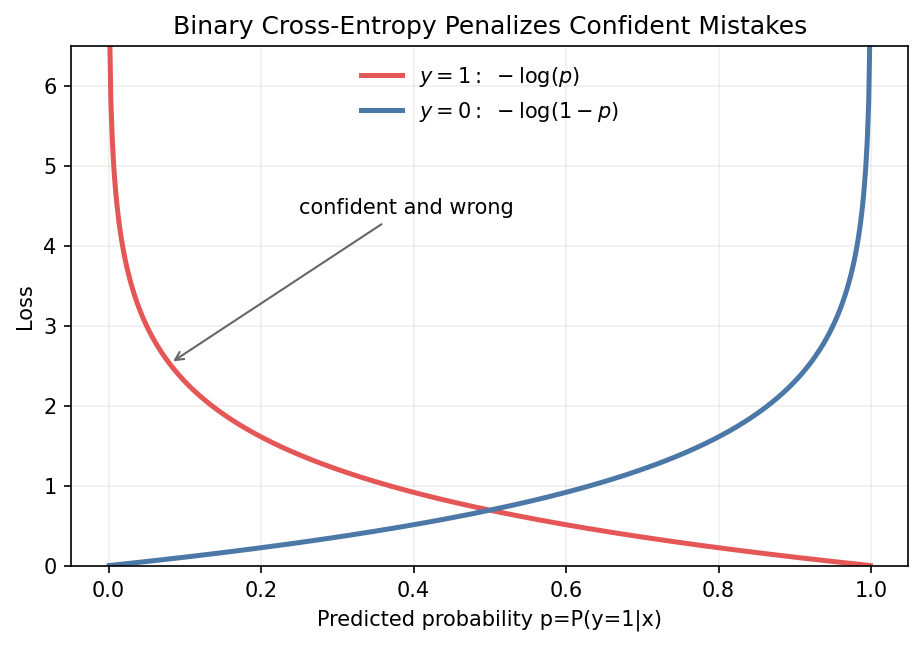

<a id="gradient"></a>
### 1.4 梯度更新：`p-y` 与参数优化

sigmoid 的导数为

$$
\frac{\mathrm d p}{\mathrm d z}=p(1-p)
$$

单个样本的损失记为

$$
\ell_i=-\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right]
$$

先对 \(p_i\) 求导，再乘上
\(\mathrm d p_i/\mathrm d z_i\)：

$$
\frac{\partial\ell_i}{\partial z_i}
=
-\left(
\frac{y_i}{p_i}
-
\frac{1-y_i}{1-p_i}
\right)p_i(1-p_i)
=
p_i-y_i
$$

这个结果可以直观理解：

- 若 \(y_i=1\)，梯度为 \(p_i-1<0\)，梯度下降会增大 \(z_i\)，
  从而增大 \(p_i\)；
- 若 \(y_i=0\)，梯度为 \(p_i>0\)，梯度下降会减小 \(z_i\)，
  从而减小 \(p_i\)。

把截距并入参数：

$$
\widetilde{\boldsymbol X}=[\boldsymbol 1,\boldsymbol X],
\qquad
\boldsymbol\theta=[b,\boldsymbol w^\mathrm T]^\mathrm T
$$

全部样本的梯度为

$$
\nabla_{\boldsymbol\theta}J
=
\frac1n
\widetilde{\boldsymbol X}^\mathrm T
(\boldsymbol p-\boldsymbol y)
$$

梯度下降更新参数：

$$
\boldsymbol\theta
\leftarrow
\boldsymbol\theta-\eta\nabla_{\boldsymbol\theta}J
$$

逻辑回归的 Hessian 可以写成

$$
\nabla^2J
=
\frac1n\widetilde{\boldsymbol X}^\mathrm T
\boldsymbol R\widetilde{\boldsymbol X}
\succeq0,
\qquad
R_{ii}=p_i(1-p_i)\ge0
$$

因此交叉熵关于参数是凸函数；梯度下降收敛后得到的是全局最优解。

<a id="metrics"></a>
### 1.5 分类决策：概率阈值与评估指标

梯度下降得到参数后，模型先输出概率 \(p\)。预测阶段再使用阈值把概率
变成类别：

$$
\hat y=
\begin{cases}
1,&p\ge0.5\\
0,&p<0.5
\end{cases}
$$

到这里，逻辑回归已经完成了从输入特征到类别预测的全过程。

<a id="full-chain"></a>
### 1.6 完整链路：从特征到类别

1. 输入特征，计算线性得分
   \(z=\boldsymbol w^\mathrm T\boldsymbol x+b\)；
2. 假设类别 1 的对数几率等于线性得分；
3. 反解对数几率方程，得到概率 \(p=\sigma(z)\)；
4. 把 \(p\) 作为 Bernoulli 分布的参数；
5. 将独立样本概率相乘，得到联合似然；
6. 最大化似然，等价于最小化二元交叉熵；
7. 链式法则得到梯度
   \(\nabla J=\widetilde{\boldsymbol X}^\mathrm T
   (\boldsymbol p-\boldsymbol y)/n\)；
8. 梯度下降更新 \(\boldsymbol w,b\)，直到 Loss 收敛；
9. 对新样本输出概率，再通过阈值得到类别。

```text
二分类问题
→ 无界线性得分
→ 对数几率线性化
→ sigmoid 概率
→ Bernoulli 似然
→ 二元交叉熵
→ 梯度下降
→ 概率
→ 类别
```

<a id="formula-code"></a>
### 1.7 代码对应：公式与实现

| 原理 | 手写实现 |
|---|---|
| 线性得分 \(z=\widetilde X\theta\) | `z = X_b @ self.theta_` |
| 概率 \(p=\sigma(z)\) | `probability = self._sigmoid(z)` |
| 梯度 \(\frac1n\widetilde X^\mathrm T(p-y)\) | `gradient = (X_b.T @ (probability - y)) / len(X)` |
| 参数更新 | `self.theta_ -= self.learning_rate * gradient` |
| 分类阈值 | `(probability >= threshold).astype(int)` |

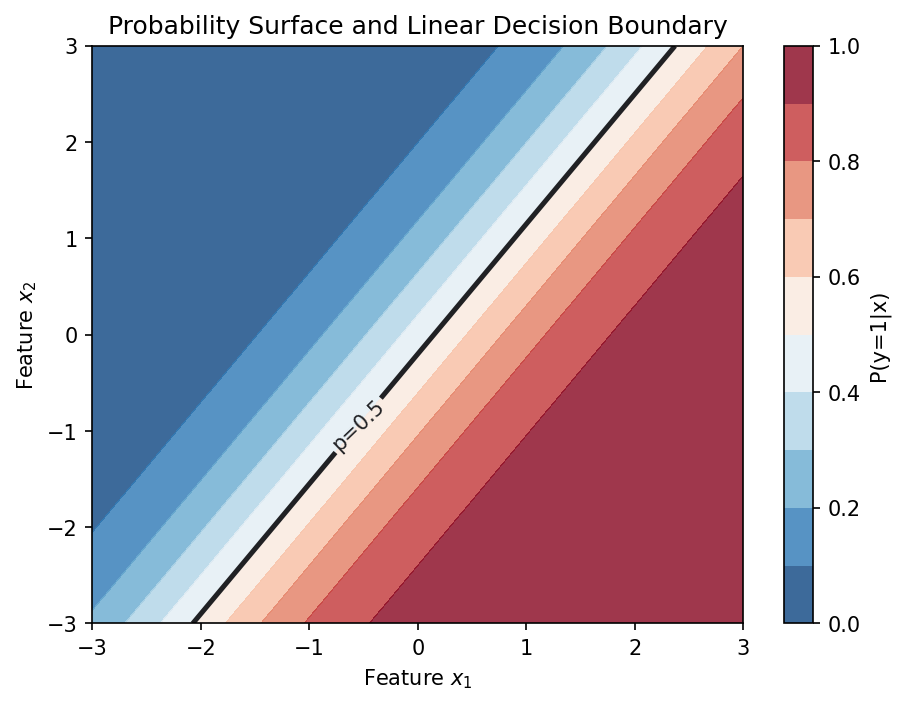

<a id="scratch"></a>
## 2. NumPy 手写逻辑回归

<a id="figure-code"></a>
### 2.1 图形复现：三张核心原理图

以下代码与原理部分的三张嵌入图一一对应。

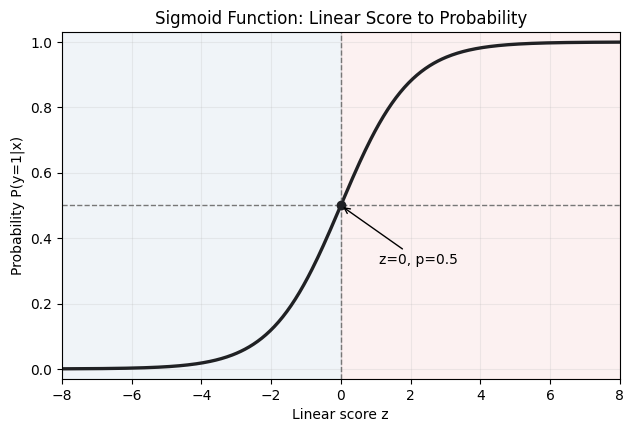

In [1]:
# 复现图 1：Sigmoid
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 400)
p = 1 / (1 + np.exp(-z))
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.axvspan(-8, 0, color="#4C78A8", alpha=0.08)
ax.axvspan(0, 8, color="#E45756", alpha=0.08)
ax.plot(z, p, color="#202124", linewidth=2.4, label=r"$p=\sigma(z)$")
ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1)
ax.axvline(0, color="#777777", linestyle="--", linewidth=1)
ax.scatter([0], [0.5], color="#202124", zorder=3)
ax.annotate("z=0, p=0.5", xy=(0, 0.5), xytext=(1.1, 0.32),
            arrowprops={"arrowstyle": "->"})
ax.set(xlabel="Linear score z", ylabel="Probability P(y=1|x)",
       title="Sigmoid Function: Linear Score to Probability", xlim=(-8, 8), ylim=(-0.03, 1.03))
ax.grid(alpha=0.2)
plt.show()

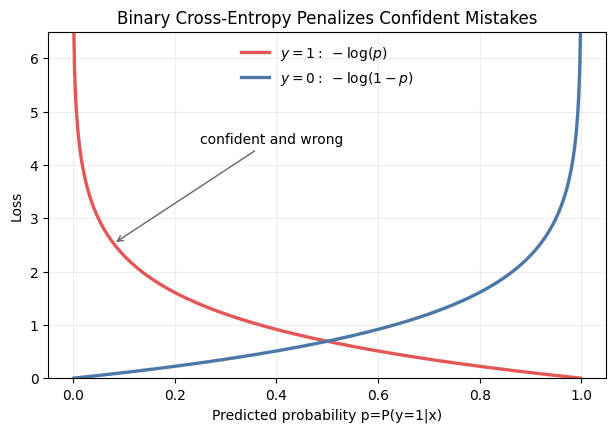

In [2]:
# 复现图 2：二元交叉熵
p_grid = np.linspace(0.001, 0.999, 500)
fig, ax = plt.subplots(figsize=(7.2, 4.5))
ax.plot(p_grid, -np.log(p_grid), color="#E45756", linewidth=2.4,
        label=r"$y=1:\ -\log(p)$")
ax.plot(p_grid, -np.log(1 - p_grid), color="#4C78A8", linewidth=2.4,
        label=r"$y=0:\ -\log(1-p)$")
ax.annotate("confident and wrong", xy=(0.08, -np.log(0.08)), xytext=(0.25, 4.4),
            arrowprops={"arrowstyle": "->", "color": "#666666"})
ax.set(xlabel="Predicted probability p=P(y=1|x)", ylabel="Loss",
       title="Binary Cross-Entropy Penalizes Confident Mistakes", ylim=(0, 6.5))
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

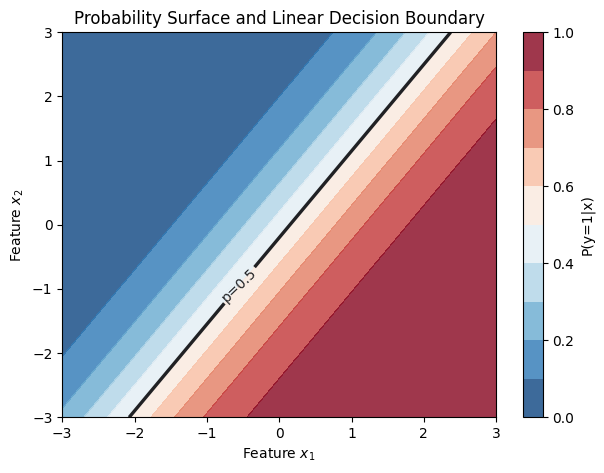

In [3]:
# 复现图 3：概率分布与决策边界
x1_grid, x2_grid = np.meshgrid(np.linspace(-3, 3, 240), np.linspace(-3, 3, 240))
score_grid = 1.35 * x1_grid - 1.0 * x2_grid - 0.2
probability_grid = 1 / (1 + np.exp(-score_grid))
fig, ax = plt.subplots(figsize=(7.0, 5.0))
filled = ax.contourf(x1_grid, x2_grid, probability_grid,
                     levels=np.linspace(0, 1, 11), cmap="RdBu_r", alpha=0.82)
boundary = ax.contour(x1_grid, x2_grid, probability_grid,
                      levels=[0.5], colors="#202124", linewidths=2.4)
ax.clabel(boundary, fmt={0.5: "p=0.5"})
fig.colorbar(filled, ax=ax, label="P(y=1|x)")
ax.set(xlabel=r"Feature $x_1$", ylabel=r"Feature $x_2$",
       title="Probability Surface and Linear Decision Boundary")
plt.show()

<a id="scratch-data"></a>
### 2.2 数据准备：二维高斯模拟数据

本节没有使用外部数据集，而是使用 NumPy 生成的二维高斯模拟数据：

$$
\boldsymbol x\mid y=0
\sim\mathcal N((-1.2,-0.8),1.05^2\boldsymbol I)
$$

$$
\boldsymbol x\mid y=1
\sim\mathcal N((1.2,0.8),1.05^2\boldsymbol I)
$$

每类生成 150 个样本，固定随机种子为 42，再按 80%/20% 划分训练集和
测试集。标准化只使用训练集的均值与标准差，避免测试数据泄漏。

选择二维模拟数据，是因为它可以直接画出 sigmoid 概率区域、决策边界和
错分点。真实数据通常维度较高，无法在平面上完整展示这些概念。

接下来只使用 NumPy 完成数据处理、sigmoid、交叉熵、梯度下降和预测。

In [4]:
import numpy as np

rng = np.random.default_rng(42)
class_0 = rng.normal(
    loc=(-1.2, -0.8),
    scale=1.05,
    size=(150, 2),
)
class_1 = rng.normal(
    loc=(1.2, 0.8),
    scale=1.05,
    size=(150, 2),
)

manual_X = np.vstack([class_0, class_1])
manual_y = np.r_[
    np.zeros(len(class_0)),
    np.ones(len(class_1)),
]

indices = rng.permutation(len(manual_X))
split = int(0.8 * len(manual_X))
train_idx, test_idx = indices[:split], indices[split:]

manual_X_train = manual_X[train_idx]
manual_X_test = manual_X[test_idx]
manual_y_train = manual_y[train_idx]
manual_y_test = manual_y[test_idx]

train_mean = manual_X_train.mean(axis=0)
train_std = manual_X_train.std(axis=0)
manual_X_train = (
    manual_X_train - train_mean
) / train_std
manual_X_test = (
    manual_X_test - train_mean
) / train_std

<a id="scratch-model"></a>
### 2.3 模型实现：`LogisticRegressionGD`

`fit` 用梯度下降学习参数；`predict_proba` 输出类别 1 的概率；
`predict` 再使用阈值把概率转换成 0 或 1。

In [5]:
class LogisticRegressionGD:
    '''使用批量梯度下降实现的教学版逻辑回归。'''

    def __init__(self, learning_rate=0.1, epochs=2000):
        self.learning_rate = learning_rate
        self.epochs = epochs

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        X_b = np.c_[np.ones(len(X)), X]

        self.theta_ = np.zeros(X_b.shape[1])
        self.loss_history_ = []
        epsilon = 1e-12

        for _ in range(self.epochs):
            z = X_b @ self.theta_
            probability = self._sigmoid(z)
            gradient = (
                X_b.T @ (probability - y)
            ) / len(X)
            self.theta_ -= (
                self.learning_rate * gradient
            )

            updated_probability = self._sigmoid(
                X_b @ self.theta_
            )
            updated_probability = np.clip(
                updated_probability,
                epsilon,
                1 - epsilon,
            )
            loss = -np.mean(
                y * np.log(updated_probability)
                + (1 - y)
                * np.log(1 - updated_probability)
            )
            self.loss_history_.append(loss)

        self.intercept_ = self.theta_[0]
        self.coef_ = self.theta_[1:]
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        X_b = np.c_[np.ones(len(X)), X]
        return self._sigmoid(X_b @ self.theta_)

    def predict(self, X, threshold=0.5):
        probability = self.predict_proba(X)
        return (probability >= threshold).astype(int)

<a id="scratch-evaluation"></a>
### 2.4 训练评估：Loss、边界与分类指标

`fit` 阶段最小化连续、可导的交叉熵。为什么不用 Accuracy 训练？
因为 Accuracy 只在预测类别越过阈值时才发生跳变，不能提供稳定梯度。

模型训练完成后，再在测试集上统计混淆矩阵：

- TP：真实为 1、预测为 1；
- TN：真实为 0、预测为 0；
- FP：真实为 0、预测为 1；
- FN：真实为 1、预测为 0。

$$
\mathrm{Accuracy}
=\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\mathrm{Precision}
=\frac{TP}{TP+FP},
\qquad
\mathrm{Recall}
=\frac{TP}{TP+FN}
$$

$$
F_1
=
\frac{2\cdot\mathrm{Precision}\cdot\mathrm{Recall}}
{\mathrm{Precision}+\mathrm{Recall}}
$$

Loss 用来学习参数；这些指标用来评价阈值分类后的结果。

In [6]:
manual_model = LogisticRegressionGD().fit(
    manual_X_train,
    manual_y_train,
)
manual_probability = manual_model.predict_proba(
    manual_X_test
)
manual_pred = manual_model.predict(manual_X_test)

manual_accuracy = np.mean(
    manual_pred == manual_y_test
)
manual_tp = np.sum(
    (manual_pred == 1) & (manual_y_test == 1)
)
manual_fp = np.sum(
    (manual_pred == 1) & (manual_y_test == 0)
)
manual_fn = np.sum(
    (manual_pred == 0) & (manual_y_test == 1)
)
manual_tn = np.sum(
    (manual_pred == 0) & (manual_y_test == 0)
)
manual_precision = manual_tp / (
    manual_tp + manual_fp
)
manual_recall = manual_tp / (
    manual_tp + manual_fn
)
manual_f1 = (
    2
    * manual_precision
    * manual_recall
    / (manual_precision + manual_recall)
)
manual_confusion = np.array(
    [
        [manual_tn, manual_fp],
        [manual_fn, manual_tp],
    ]
)

print(f"Accuracy: {manual_accuracy:.4f}")
print(f"Precision: {manual_precision:.4f}")
print(f"Recall: {manual_recall:.4f}")
print(f"F1: {manual_f1:.4f}")

assert (
    manual_model.loss_history_[-1]
    < manual_model.loss_history_[0]
)
assert np.all(
    (manual_probability >= 0)
    & (manual_probability <= 1)
)
assert 0.88 <= manual_accuracy <= 0.98
print("手写模型验证通过。")

Accuracy: 0.9167
Precision: 0.8889
Recall: 0.9231
F1: 0.9057
手写模型验证通过。


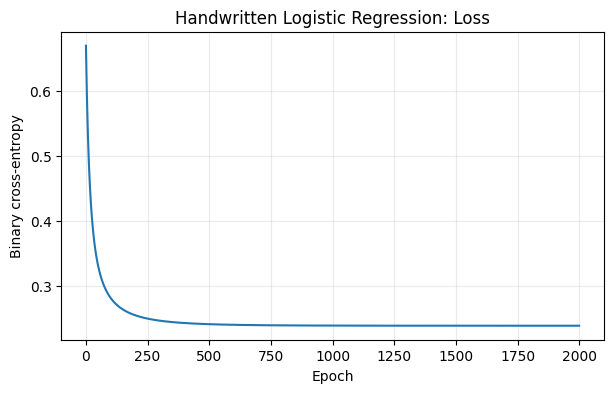

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(manual_model.loss_history_)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Handwritten Logistic Regression: Loss")
plt.grid(alpha=0.25)
plt.show()

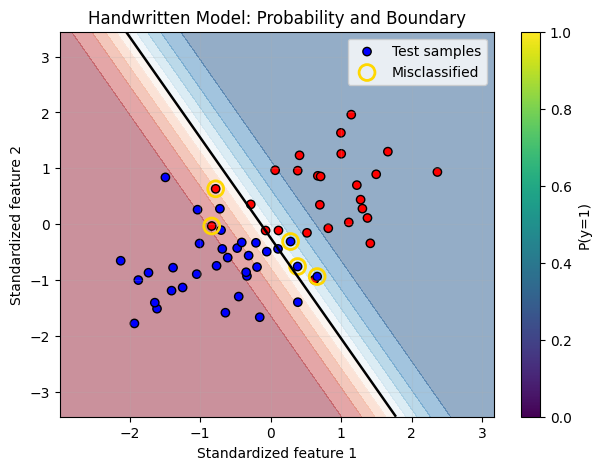

In [8]:
manual_x1_min = min(
    manual_X_train[:, 0].min(),
    manual_X_test[:, 0].min(),
) - 0.8
manual_x1_max = max(
    manual_X_train[:, 0].max(),
    manual_X_test[:, 0].max(),
) + 0.8
manual_x2_min = min(
    manual_X_train[:, 1].min(),
    manual_X_test[:, 1].min(),
) - 0.8
manual_x2_max = max(
    manual_X_train[:, 1].max(),
    manual_X_test[:, 1].max(),
) + 0.8

manual_grid_x1, manual_grid_x2 = np.meshgrid(
    np.linspace(manual_x1_min, manual_x1_max, 250),
    np.linspace(manual_x2_min, manual_x2_max, 250),
)
manual_grid = np.c_[
    manual_grid_x1.ravel(),
    manual_grid_x2.ravel(),
]
manual_grid_probability = (
    manual_model.predict_proba(manual_grid).reshape(
        manual_grid_x1.shape
    )
)

plt.figure(figsize=(7, 5))
plt.contourf(
    manual_grid_x1,
    manual_grid_x2,
    manual_grid_probability,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu",
    alpha=0.45,
)
plt.contour(
    manual_grid_x1,
    manual_grid_x2,
    manual_grid_probability,
    levels=[0.5],
    colors="black",
    linewidths=1.8,
)
plt.scatter(
    manual_X_test[:, 0],
    manual_X_test[:, 1],
    c=manual_y_test,
    cmap="bwr",
    edgecolor="black",
    label="Test samples",
)

misclassified = manual_pred != manual_y_test
plt.scatter(
    manual_X_test[misclassified, 0],
    manual_X_test[misclassified, 1],
    facecolors="none",
    edgecolors="gold",
    linewidths=2,
    s=130,
    label="Misclassified",
)
plt.xlabel("Standardized feature 1")
plt.ylabel("Standardized feature 2")
plt.title("Handwritten Model: Probability and Boundary")
plt.colorbar(label="P(y=1)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

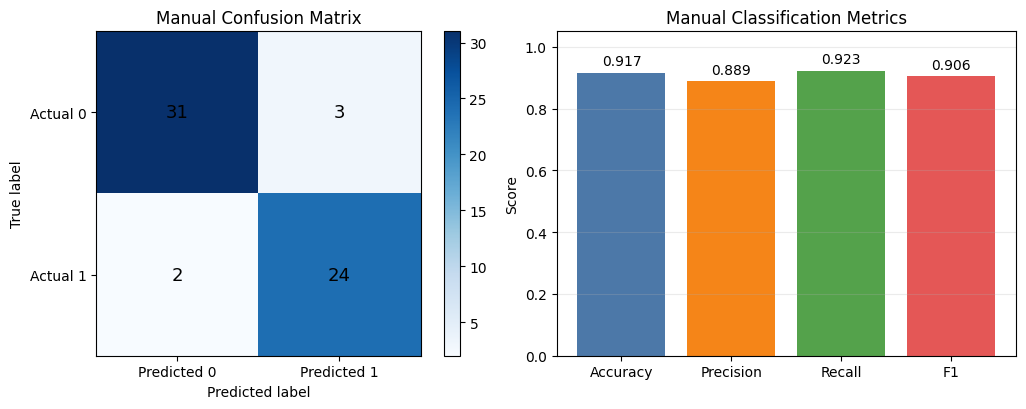

In [9]:
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
]
metric_values = [
    manual_accuracy,
    manual_precision,
    manual_recall,
    manual_f1,
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.2),
)

image = axes[0].imshow(
    manual_confusion,
    cmap="Blues",
)
for row in range(2):
    for column in range(2):
        axes[0].text(
            column,
            row,
            manual_confusion[row, column],
            ha="center",
            va="center",
            fontsize=13,
        )
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Predicted 0", "Predicted 1"])
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["Actual 0", "Actual 1"])
axes[0].set_xlabel("Predicted label")
axes[0].set_ylabel("True label")
axes[0].set_title("Manual Confusion Matrix")
figure.colorbar(image, ax=axes[0], fraction=0.046)

bars = axes[1].bar(
    metric_names,
    metric_values,
    color=["#4C78A8", "#F58518", "#54A24B", "#E45756"],
)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Score")
axes[1].set_title("Manual Classification Metrics")
axes[1].grid(axis="y", alpha=0.25)
axes[1].bar_label(
    bars,
    labels=[f"{value:.3f}" for value in metric_values],
    padding=3,
)

figure.tight_layout()
plt.show()

<a id="sklearn"></a>
## 3. sklearn 调用与案例

<a id="sklearn-basic"></a>
### 3.1 分类调用：决策边界与指标评估

完整流程：生成或加载数据 → 划分训练集与测试集 → 标准化
→ `fit` → `predict_proba` / `predict` → 指标 → 可视化。

In [10]:
from sklearn.datasets import (
    load_breast_cancer,
    make_classification,
)
from IPython.display import HTML, display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def display_result_table(title, headers, rows, hidden_comment=""):
    header_html = "".join(
        f'<th style="padding:8px 12px;text-align:left;background:#eef3ff">{header}</th>'
        for header in headers
    )
    row_html = "".join(
        "<tr>" + "".join(
            f'<td style="padding:7px 12px;border-top:1px solid #dde3ee">{value}</td>'
            for value in row
        ) + "</tr>"
        for row in rows
    )
    comment_html = f"<!-- {hidden_comment} -->" if hidden_comment else ""
    display(HTML(
        f'<div style="max-width:780px"><h4>{title}</h4>'
        f'<table style="border-collapse:collapse;width:100%;font-size:14px">'
        f'<thead><tr>{header_html}</tr></thead><tbody>{row_html}</tbody></table>'
        f'{comment_html}</div>'
    ))


def evaluate_classifier(y_true, y_pred, y_probability):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(
            y_true,
            y_probability,
        ),
    }


basic_X, basic_y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42,
)
(
    basic_X_train,
    basic_X_test,
    basic_y_train,
    basic_y_test,
) = train_test_split(
    basic_X,
    basic_y,
    test_size=0.2,
    stratify=basic_y,
    random_state=42,
)

basic_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)
basic_model.fit(basic_X_train, basic_y_train)
basic_probability = basic_model.predict_proba(
    basic_X_test
)[:, 1]
basic_pred = basic_model.predict(basic_X_test)
basic_metrics = evaluate_classifier(
    basic_y_test,
    basic_pred,
    basic_probability,
)

print("基础示例")
for name, value in basic_metrics.items():
    print(f"{name}: {value:.4f}")

基础示例
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1: 1.0000
ROC-AUC: 1.0000


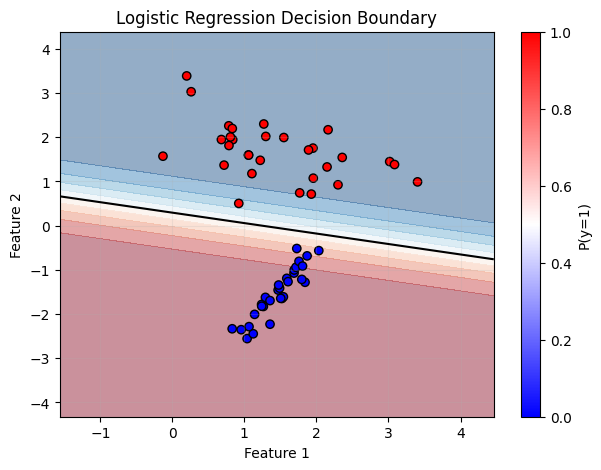

In [11]:
margin = 1.0
x1_min = basic_X[:, 0].min() - margin
x1_max = basic_X[:, 0].max() + margin
x2_min = basic_X[:, 1].min() - margin
x2_max = basic_X[:, 1].max() + margin
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250),
)
grid = np.c_[grid_x1.ravel(), grid_x2.ravel()]
grid_probability = basic_model.predict_proba(
    grid
)[:, 1].reshape(grid_x1.shape)

plt.figure(figsize=(7, 5))
plt.contourf(
    grid_x1,
    grid_x2,
    grid_probability,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu",
    alpha=0.45,
)
plt.contour(
    grid_x1,
    grid_x2,
    grid_probability,
    levels=[0.5],
    colors="black",
    linewidths=1.5,
)
plt.scatter(
    basic_X_test[:, 0],
    basic_X_test[:, 1],
    c=basic_y_test,
    cmap="bwr",
    edgecolor="black",
    label="Test samples",
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.colorbar(label="P(y=1)")
plt.grid(alpha=0.2)
plt.show()

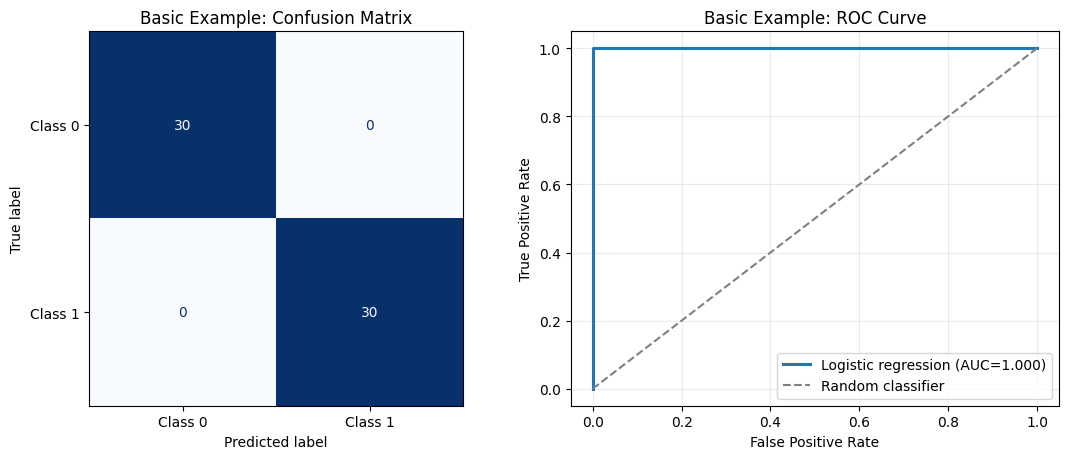

In [12]:
basic_false_positive_rate, basic_true_positive_rate, _ = roc_curve(
    basic_y_test,
    basic_probability,
)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7))
ConfusionMatrixDisplay.from_predictions(
    basic_y_test,
    basic_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Basic Example: Confusion Matrix")
axes[0].grid(False)

axes[1].plot(
    basic_false_positive_rate,
    basic_true_positive_rate,
    linewidth=2.2,
    label=f"Logistic regression (AUC={basic_metrics['ROC-AUC']:.3f})",
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Random classifier")
axes[1].set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Basic Example: ROC Curve",
)
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

决策边界说明模型在二维空间中怎样分区；混淆矩阵显示具体错分数量，
ROC-AUC 则综合衡量模型在不同分类阈值下区分两类样本的能力。

<a id="real-case"></a>
### 3.2 分类案例：乳腺癌良恶性诊断

`load_breast_cancer` 包含肿瘤细胞核的半径、纹理、周长、面积等特征。
目标是判断样本属于恶性还是良性。这里沿用数据集的原始标签定义，
并使用全部 30 个特征。

30 维模型的真实决策边界无法直接画在二维平面。下面保留全部特征模型作为正式评估，
再单独建立一个 **PCA 二维投影模型**绘制边界；该图只帮助理解分区，不代替 30 维模型的指标。
因此它应读作：**PCA 二维投影边界（仅用于可视化）**。

In [13]:
cancer = load_breast_cancer()
(
    real_X_train,
    real_X_test,
    real_y_train,
    real_y_test,
) = train_test_split(
    cancer.data,
    cancer.target,
    test_size=0.2,
    stratify=cancer.target,
    random_state=42,
)

real_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=3000),
)
real_model.fit(real_X_train, real_y_train)
real_probability = real_model.predict_proba(
    real_X_test
)[:, 1]
real_pred = real_model.predict(real_X_test)
real_metrics = evaluate_classifier(
    real_y_test,
    real_pred,
    real_probability,
)

print("真实场景：乳腺肿瘤良恶性分类")
print(f"样本数: {cancer.data.shape[0]}")
print(f"特征数: {cancer.data.shape[1]}")
for name, value in real_metrics.items():
    print(f"{name}: {value:.4f}")

display_result_table(
    "乳腺癌逻辑回归真实案例指标表",
    ["指标", "数值", "含义"],
    [
        ["Accuracy", f'{real_metrics["Accuracy"]:.3f}', "总体预测正确率"],
        ["Precision", f'{real_metrics["Precision"]:.3f}', "预测为正类时的准确程度"],
        ["Recall", f'{real_metrics["Recall"]:.3f}', "实际正类被识别的比例"],
        ["F1", f'{real_metrics["F1"]:.3f}', "Precision 与 Recall 的调和平均"],
        ["ROC-AUC", f'{real_metrics["ROC-AUC"]:.3f}', "全部阈值下的排序能力"],
    ],
)

真实场景：乳腺肿瘤良恶性分类
样本数: 569
特征数: 30
Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1: 0.9861
ROC-AUC: 0.9954


指标,数值,含义
Accuracy,0.982,总体预测正确率
Precision,0.986,预测为正类时的准确程度
Recall,0.986,实际正类被识别的比例
F1,0.986,Precision 与 Recall 的调和平均
ROC-AUC,0.995,全部阈值下的排序能力


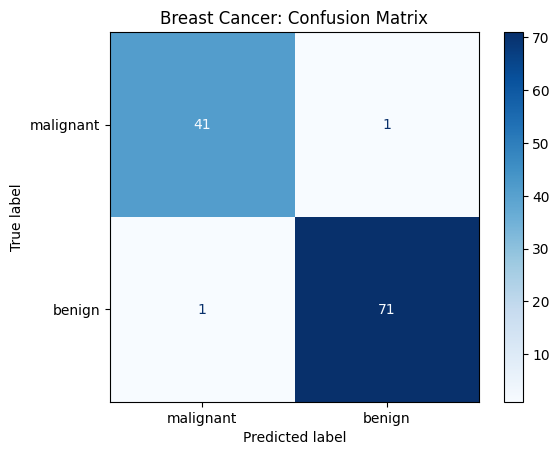

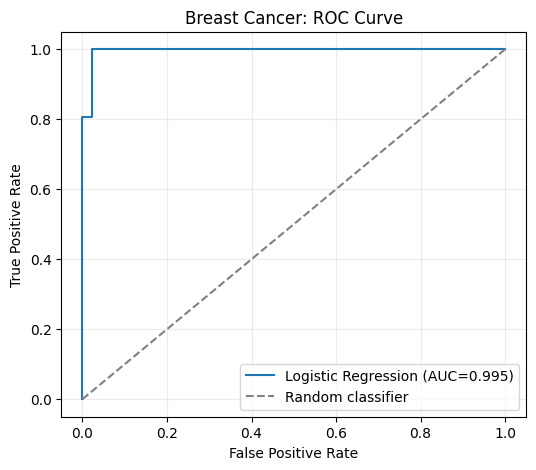

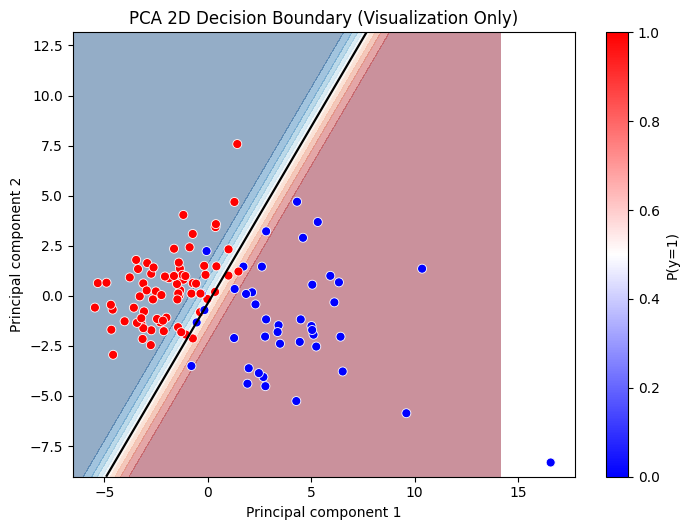

In [14]:
ConfusionMatrixDisplay.from_predictions(
    real_y_test,
    real_pred,
    display_labels=cancer.target_names,
    cmap="Blues",
)
plt.title("Breast Cancer: Confusion Matrix")
plt.grid(False)
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(
    real_y_test,
    real_probability,
)
plt.figure(figsize=(6, 5))
plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        "Logistic Regression "
        f"(AUC={real_metrics['ROC-AUC']:.3f})"
    ),
)
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random classifier",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Breast Cancer: ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

real_visual_scaler = StandardScaler()
real_X_train_scaled = real_visual_scaler.fit_transform(real_X_train)
real_X_test_scaled = real_visual_scaler.transform(real_X_test)
real_visual_pca = PCA(n_components=2, random_state=42)
real_X_train_pca = real_visual_pca.fit_transform(real_X_train_scaled)
real_X_test_pca = real_visual_pca.transform(real_X_test_scaled)
real_visual_model = LogisticRegression(max_iter=3000).fit(
    real_X_train_pca,
    real_y_train,
)

pca_margin = 1.0
pca_x_min, pca_x_max = (
    real_X_train_pca[:, 0].min() - pca_margin,
    real_X_train_pca[:, 0].max() + pca_margin,
)
pca_y_min, pca_y_max = (
    real_X_train_pca[:, 1].min() - pca_margin,
    real_X_train_pca[:, 1].max() + pca_margin,
)
pca_grid_x, pca_grid_y = np.meshgrid(
    np.linspace(pca_x_min, pca_x_max, 280),
    np.linspace(pca_y_min, pca_y_max, 280),
)
pca_grid = np.c_[pca_grid_x.ravel(), pca_grid_y.ravel()]
pca_probability = real_visual_model.predict_proba(pca_grid)[:, 1].reshape(
    pca_grid_x.shape
)

plt.figure(figsize=(7.2, 5.4))
plt.contourf(
    pca_grid_x,
    pca_grid_y,
    pca_probability,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu",
    alpha=0.45,
)
plt.contour(
    pca_grid_x,
    pca_grid_y,
    pca_probability,
    levels=[0.5],
    colors="black",
    linewidths=1.6,
)
plt.scatter(
    real_X_test_pca[:, 0],
    real_X_test_pca[:, 1],
    c=real_y_test,
    cmap="bwr",
    edgecolor="white",
    linewidth=0.6,
    s=42,
)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.title("PCA 2D Decision Boundary (Visualization Only)")
plt.colorbar(label="P(y=1)")
plt.tight_layout()
plt.show()

<a id="summary"></a>
## 4. 章节小结

- 逻辑回归通过 Sigmoid 把线性得分转换为类别概率。
- Bernoulli 最大似然等价于最小化二元交叉熵，梯度核心形式为 p-y。
- 分类评估结合决策边界、指标、混淆矩阵和 ROC，而不是只看 Accuracy。
- 高维真实案例不强行绘制二维边界，重点检查错分与阈值表现。
- 书籍、GitHub 项目和官方文档已列在本章开头。

In [15]:
import json

all_metrics = [
    manual_accuracy,
    manual_precision,
    manual_recall,
    manual_f1,
    *basic_metrics.values(),
    *real_metrics.values(),
]
assert np.all(np.isfinite(all_metrics))
assert basic_metrics["Accuracy"] > 0.85
assert real_metrics["Accuracy"] > 0.90
validation = {
    "manual_accuracy": float(manual_accuracy),
    "manual_loss_start": float(manual_model.loss_history_[0]),
    "manual_loss_end": float(manual_model.loss_history_[-1]),
    "basic_accuracy": float(basic_metrics["Accuracy"]),
    "basic_roc_auc": float(basic_metrics["ROC-AUC"]),
    "real_accuracy": float(real_metrics["Accuracy"]),
    "real_roc_auc": float(real_metrics["ROC-AUC"]),
    "image_count": 11,
}
assert validation["manual_loss_end"] < validation["manual_loss_start"]

display_result_table(
    "Notebook 验证汇总（Notebook validation summary）",
    ["检查项", "观测值", "状态"],
    [
        ["手写模型 Loss", f'{validation["manual_loss_start"]:.3f} → {validation["manual_loss_end"]:.3f}', "通过"],
        ["手写模型 Accuracy", f'{validation["manual_accuracy"]:.3f}', "通过"],
        ["基础 sklearn Accuracy", f'{validation["basic_accuracy"]:.3f}', "通过"],
        ["乳腺癌 Accuracy", f'{validation["real_accuracy"]:.3f}', "通过"],
        ["乳腺癌 ROC-AUC", f'{validation["real_roc_auc"]:.3f}', "通过"],
        ["已执行图表输出", f'{validation["image_count"]}', "通过"],
    ],
    hidden_comment="VALIDATION " + json.dumps(
        validation, ensure_ascii=False, sort_keys=True
    ),
)

检查项,观测值,状态
手写模型 Loss,0.669 → 0.239,通过
手写模型 Accuracy,0.917,通过
基础 sklearn Accuracy,1.000,通过
乳腺癌 Accuracy,0.982,通过
乳腺癌 ROC-AUC,0.995,通过
已执行图表输出,11,通过
